*Name* : - - 

*Roll No.* : - -

Acknowledgement :- ChatGPT was used to assist in making this journal report

## Calculations

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
observations = pd.read_excel('PH447_Exp1.xlsx')

# print(observations.iloc[:,:5])

Angles = observations.iloc[2:,2].values
Intensities = observations.iloc[2:,4].values

# print(Angles, Intensities)

In [32]:
Max_Intensity_angle = Angles[0]
Intensities = np.array(Intensities[1:], dtype=np.float64)
Angles = np.array(Angles[1:], dtype=np.float64)
Corrected_Angles = Angles - Max_Intensity_angle

# print(Corrected_Angles, Intensities)
# print(np.deg2rad(Corrected_Angles/2))

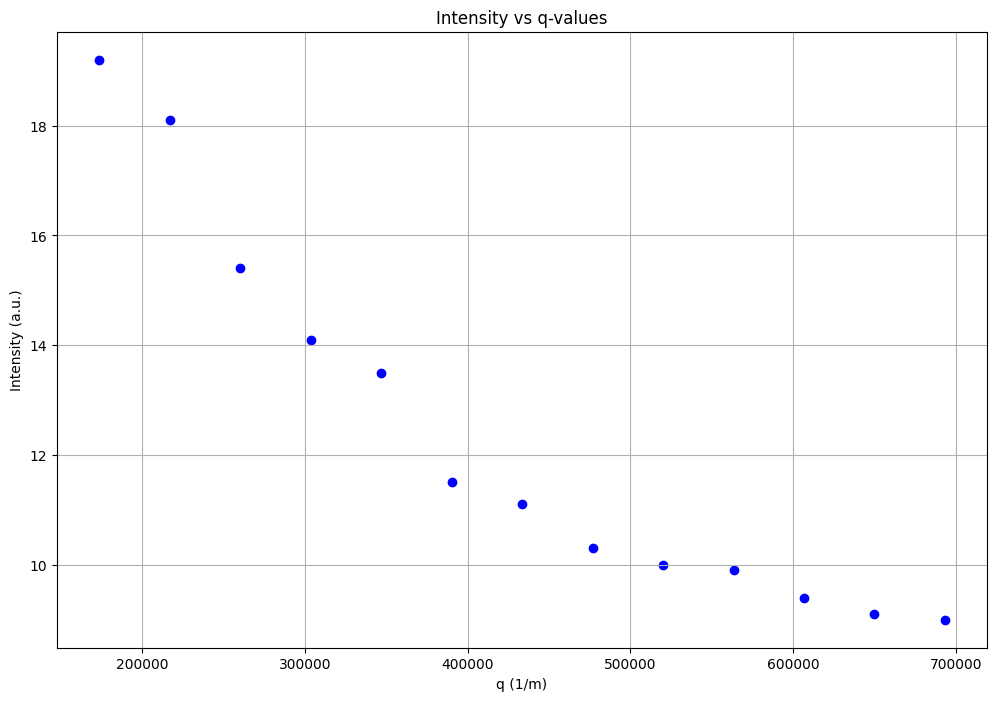

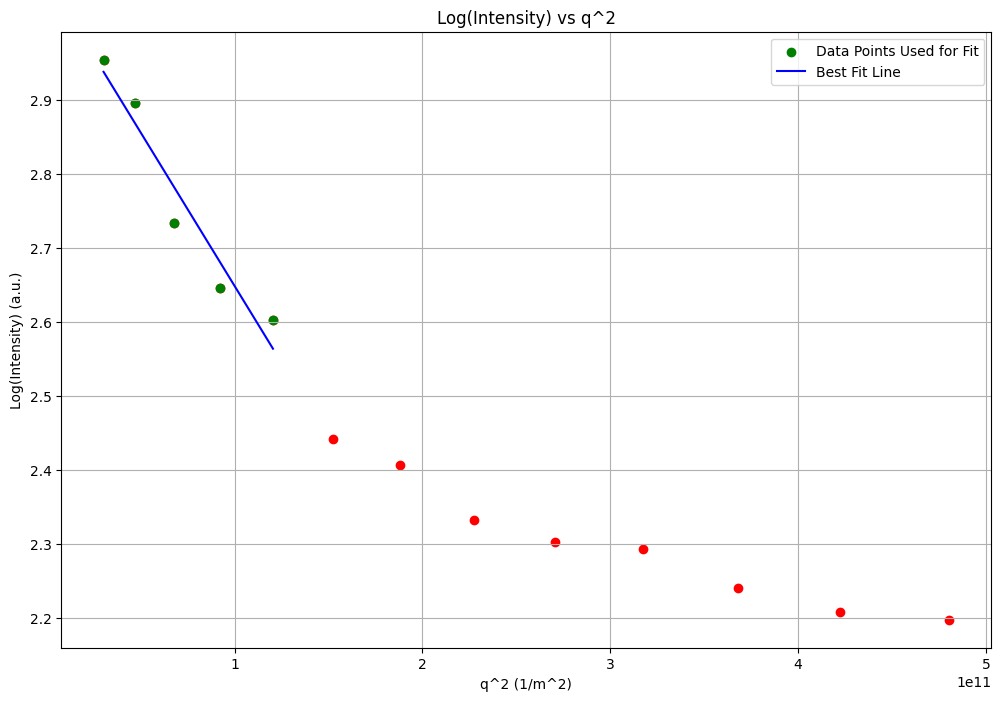

In [33]:
Wavelength = 632.8e-9

q_values = (2 * np.pi / Wavelength) * np.sin(np.deg2rad(Corrected_Angles/2))
q2_values = q_values**2
log_Intensities = np.log(Intensities)

plt.figure(figsize=(12,8))
plt.scatter(q_values, Intensities, marker='o', linestyle='-', color='b')
plt.title('Intensity vs q-values')
plt.xlabel('q (1/m)')
plt.ylabel('Intensity (a.u.)')
plt.grid()
plt.show()

Best_fit = np.polyfit(q2_values[:5], log_Intensities[:5], 1)

plt.figure(figsize=(12,8))
plt.scatter(q2_values, log_Intensities, marker='o', linestyle='-', color='r')
plt.scatter(q2_values[:5], log_Intensities[:5], marker='o', color='g', label='Data Points Used for Fit')
plt.plot(q2_values[:5], np.polyval(Best_fit, q2_values[:5]), color='b', label='Best Fit Line')
plt.title('Log(Intensity) vs q^2')
plt.xlabel('q^2 (1/m^2)')
plt.ylabel('Log(Intensity) (a.u.)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
Slope = Best_fit[0]
Error_in_Slope = np.sqrt(np.sum((log_Intensities[:5] - np.polyval(Best_fit, q2_values[:5]))**2) / (len(q2_values[:5]) - 2)) / np.sqrt(np.sum((q2_values[:5] - np.mean(q2_values[:5]))**2))
print(f"Slope: {Slope:.4e} ± {Error_in_Slope:.4e} (1/m^2)")
print()


Radius_of_Gyration = np.sqrt(-3 * Slope)
Error_in_Radius_of_Gyration = (3 / (2 * Radius_of_Gyration)) * Error_in_Slope
print(f"Radius of Gyration: {Radius_of_Gyration:.4e} ± {Error_in_Radius_of_Gyration:.4e} m or {Radius_of_Gyration*1e6:.2f} ± {Error_in_Radius_of_Gyration*1e6:.2f} um")
print()

print(f"Product of R_g and q_max: {Radius_of_Gyration * q_values[0]:.4f} (< 1.3, Valid for Guinier Approximation)")
print()

Radius_of_particle = Radius_of_Gyration * np.sqrt(5/3)
Error_in_Radius_of_particle = (np.sqrt(5/3)) * Error_in_Radius_of_Gyration
print(f"Radius of Particle: {Radius_of_particle:.4e} ± {Error_in_Radius_of_particle:.4e} m or {Radius_of_particle*1e6:.2f} ± {Error_in_Radius_of_particle*1e6:.2f} um")
print(f"Diameter of Particle: {2*Radius_of_particle:.4e} ± {2*Error_in_Radius_of_particle:.4e} m or {(2*Radius_of_particle)*1e6:.2f} ± {(2*Error_in_Radius_of_particle)*1e6:.2f} um")

Slope: -4.1523e-12 ± 6.2656e-13 (1/m^2)

Radius of Gyration: 3.5294e-06 ± 2.6628e-07 m or 3.53 ± 0.27 um

Product of R_g and q_max: 0.6132 < 1.3 (Condition for Validity of Guinier Approximation)

Radius of Particle: 4.5565e-06 ± 3.4377e-07 m or 4.56 ± 0.34 um
Diameter of Particle: 9.1130e-06 ± 6.8754e-07 m or 9.11 ± 0.69 um


## Results

In [45]:
print(f"Slope of linear fit: {Slope:.4e} ± {Error_in_Slope:.4e} (1/m^2)")
print()
print(f"Radius of Gyration: {Radius_of_Gyration*1e6:.2f} ± {Error_in_Radius_of_Gyration*1e6:.2f} um")
print()
print(f"q_max * R_g: {Radius_of_Gyration * q_values[0]:.4f} (<1.3)")
print()
print(f"Radius of Particle: {Radius_of_particle*1e6:.2f} ± {Error_in_Radius_of_particle*1e6:.2f} um")
print(f"Diameter of Particle: {2*Radius_of_particle*1e6:.2f} ± {2*Error_in_Radius_of_particle*1e6:.2f} um")

Slope of linear fit: -4.1523e-12 ± 6.2656e-13 (1/m^2)

Radius of Gyration: 3.53 ± 0.27 um

q_max * R_g: 0.6132 (<1.3)

Radius of Particle: 4.56 ± 0.34 um
Diameter of Particle: 9.11 ± 0.69 um
